In [1]:
import pandas as pd
import numpy as np

# =========================================================
# PRE PROCESSING DATA 
# =========================================================

# =========================================================
# 1. BACA DATA
# =========================================================

df = pd.read_csv(
    "taiwan_air_quality_timeseries_cokriging_raw.csv"
)

print("Ukuran data awal:", df.shape)


# =========================================================
# 2. FORMAT WAKTU
# =========================================================

df["time"] = pd.to_datetime(df["time"])


# =========================================================
# 3. PILIH VARIABEL
# =========================================================

df["PM25"] = pd.to_numeric(
    df["PM2.5_numeric_if_valid"],
    errors="coerce"
)

df["PM10"] = pd.to_numeric(
    df["PM10_numeric_if_valid"],
    errors="coerce"
)


# =========================================================
# 4. CEK MISSING VALUE
# =========================================================

print("\nMissing value:")
print(df[["PM25", "PM10"]].isnull().sum())


# =========================================================
# 5. CLEANING
# hanya PM2.5 dan PM10 yang sama-sama tersedia
# =========================================================

df_clean = df.dropna(
    subset=["PM25", "PM10"]
).copy()


# =========================================================
# 6. HAPUS NILAI NEGATIF JIKA ADA
# =========================================================

df_clean = df_clean[
    (df_clean["PM25"] >= 0) &
    (df_clean["PM10"] >= 0)
].copy()


# =========================================================
# 7. INFORMASI WAKTU
# =========================================================

df_clean["year"] = df_clean["time"].dt.year
df_clean["month"] = df_clean["time"].dt.month


# =========================================================
# 8. STATISTIK DESKRIPTIF
# =========================================================

print("\nStatistik PM2.5 dan PM10:")
print(df_clean[["PM25", "PM10"]].describe())


# =========================================================
# 9. KORELASI TIME SERIES
# =========================================================

print(
    "\nKorelasi seluruh observasi:",
    df_clean["PM25"].corr(df_clean["PM10"])
)


# =========================================================
# 10. AGREGASI PER STASIUN
# =========================================================

df_station = (
    df_clean
    .groupby("station")
    .agg(
        longitude=("longitude_twd97", "first"),
        latitude=("latitude_twd97", "first"),
        X=("x_twd97_tm2_m", "first"),
        Y=("y_twd97_tm2_m", "first"),
        PM25=("PM25", "mean"),
        PM10=("PM10", "mean"),
        jumlah_observasi=("PM25", "count")
    )
    .reset_index()
)


# =========================================================
# 11. KORELASI ANTAR LOKASI
# =========================================================

print(
    "\nKorelasi spasial PM2.5-PM10:",
    df_station["PM25"].corr(df_station["PM10"])
)


# =========================================================
# 12. LIHAT DATA AKHIR
# =========================================================

print("\nDataset akhir Co-Kriging:")
print(df_station.round(3))


# =========================================================
# 13. SIMPAN DATA
# =========================================================

df_clean.to_csv(
    "taiwan_air_quality_clean.csv",
    index=False
)

df_station.to_csv(
    "taiwan_air_quality_cokriging_station.csv",
    index=False
)

print("\nProcessing selesai.")
print("Jumlah observasi bersih:", len(df_clean))
print("Jumlah lokasi:", len(df_station))

Ukuran data awal: (218640, 13)

Missing value:
PM25    8518
PM10    6596
dtype: int64

Statistik PM2.5 dan PM10:
                PM25           PM10
count  208782.000000  208782.000000
mean       18.590741      41.812014
std        13.360173      23.861459
min         0.000000       0.000000
25%         9.000000      26.000000
50%        16.000000      37.000000
75%        24.000000      52.000000
max       131.000000     292.000000

Korelasi seluruh observasi: 0.803288224033271

Korelasi spasial PM2.5-PM10: 0.3140177152953808

Dataset akhir Co-Kriging:
      station  longitude  latitude           X            Y    PM25    PM10  \
0     Banqiao    121.459    25.013  296293.303  2767292.715  20.259  44.209   
1     Cailiao    121.481    25.069  298528.200  2773500.941  15.857  38.679   
2      Datong    121.513    25.063  301787.522  2772876.013  17.376  53.307   
3      Dayuan    121.202    25.060  270360.868  2772476.590  20.534  46.988   
4     Guanyin    121.083    25.036  258351.49

In [2]:
%pip install scikit-gstat

Note: you may need to restart the kernel to use updated packages.Defaulting to user installation because normal site-packages is not writeable




[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


INFORMASI DATA

Ukuran data: (25, 8)

5 data pertama:
   station   longitude   latitude           X            Y       PM25  \
0  Banqiao  121.458667  25.012972  296293.303  2767292.715  20.259347   
1  Cailiao  121.481028  25.068950  298528.200  2773500.941  15.857261   
2   Datong  121.513311  25.063200  301787.522  2772876.013  17.376093   
3   Dayuan  121.201811  25.060344  270360.868  2772476.590  20.534460   
4  Guanyin  121.082761  25.035503  258351.495  2769712.502  19.043147   

        PM10  jumlah_observasi  
0  44.208502              8398  
1  38.679339              8470  
2  53.306589              8575  
3  46.988178              8459  
4  50.850616              8274  

Jumlah stasiun: 25

STATISTIK DESKRIPTIF
            PM25       PM10
count  25.000000  25.000000
mean   18.582567  41.780683
std     2.444032   8.399669
min    12.012839  17.237766
25%    17.603797  37.359054
50%    18.509853  40.333807
75%    20.534460  47.058921
max    23.153691  55.782006

Median PM2.5 :

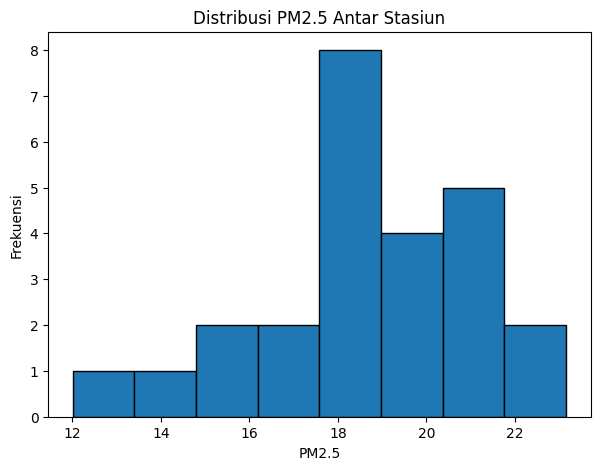

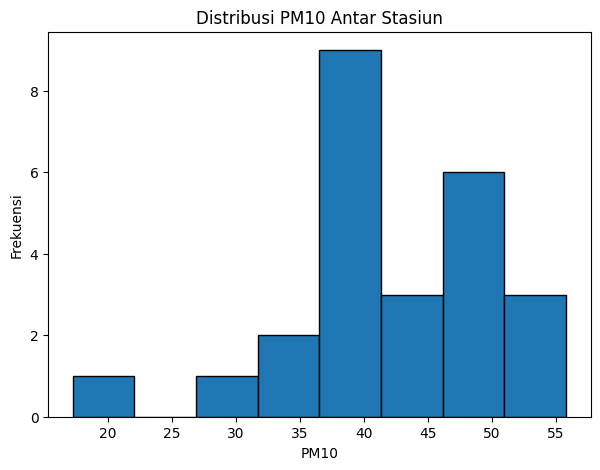

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3356\2665380254.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


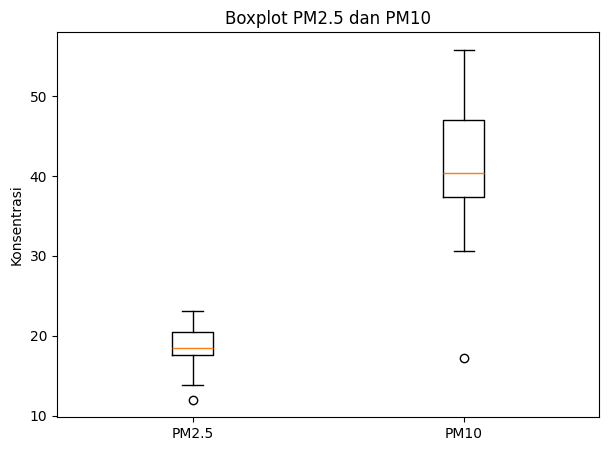

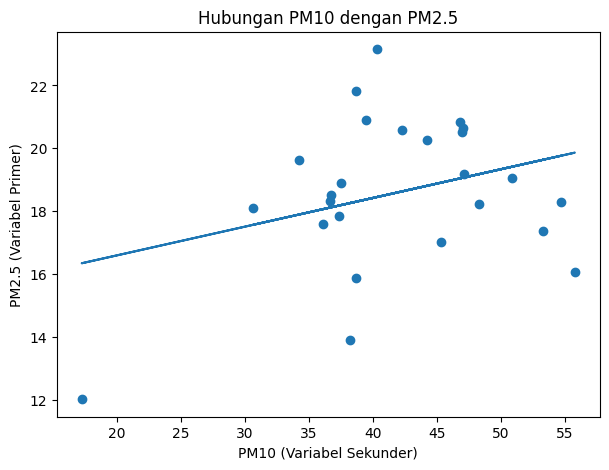

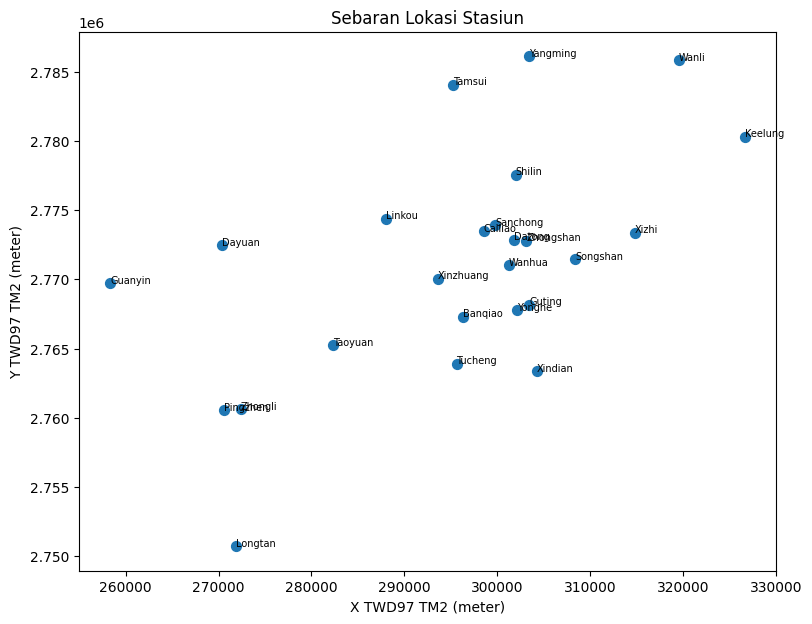

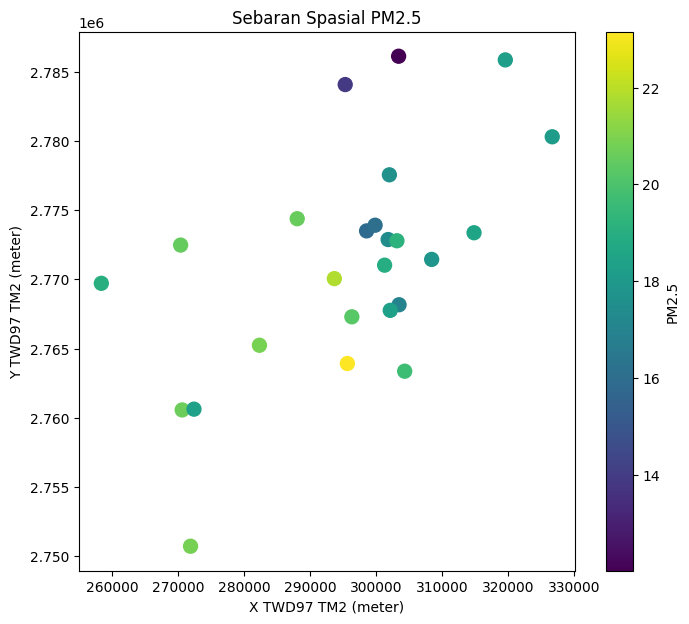

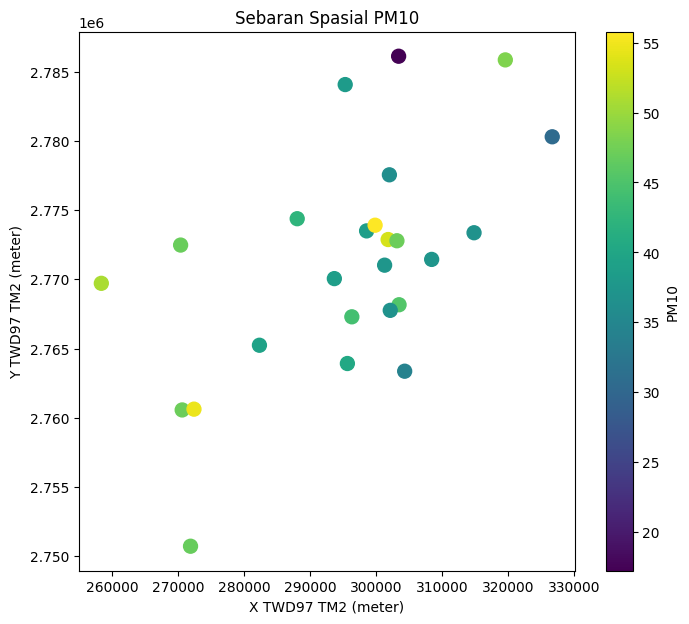


JARAK ANTAR STASIUN
Jarak minimum : 1.34 km
Jarak maksimum: 69.11 km
Jarak rata-rata: 21.89 km


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\skgstat\plotting\variogram_plot.py:123: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


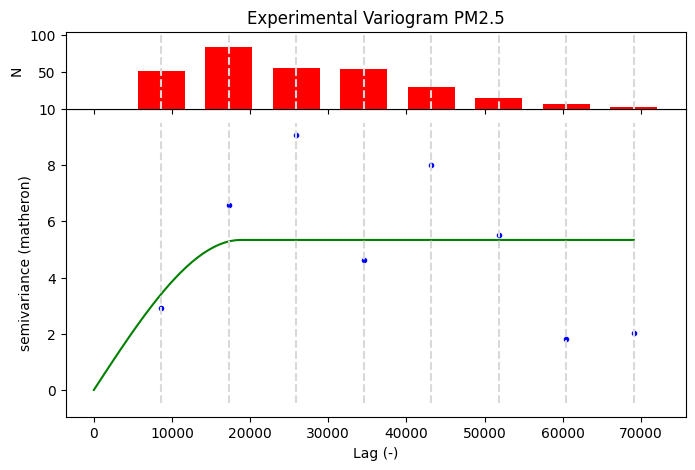


Parameter Variogram PM2.5:
[np.float64(18807.716440888904), np.float64(5.338930004965239), 0]


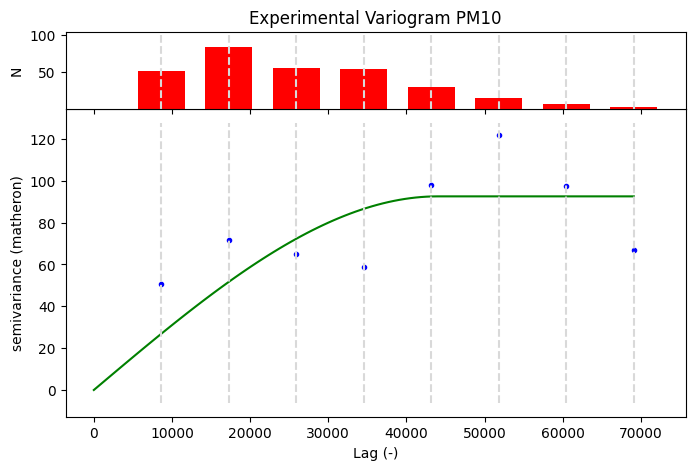


Parameter Variogram PM10:
[np.float64(44010.693983573474), np.float64(92.54091813925626), 0]


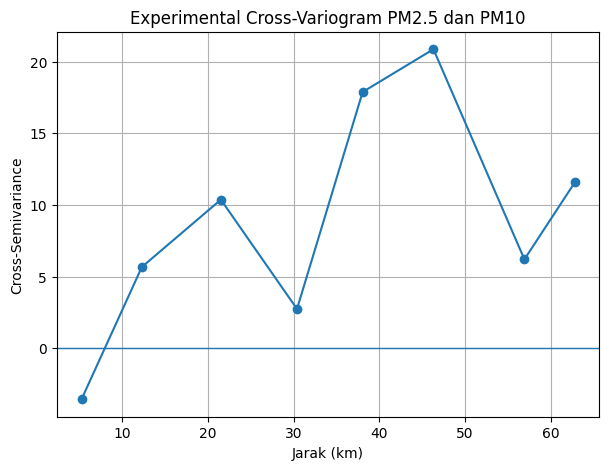


CROSS-VARIOGRAM
   Jarak_km  Cross_Semivariance  Jumlah_Pasangan
0    5.2997             -3.5590               52
1   12.3260              5.6665               84
2   21.5334             10.3652               55
3   30.4040              2.7380               54
4   38.0529             17.8748               30
5   46.3019             20.8590               15
6   56.9019              6.1973                7
7   62.7675             11.5614                2


In [3]:
# ============================================================
# TAHAP 2 - EKSPLORASI DATA DAN ANALISIS SPASIAL
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import shapiro
from scipy.spatial.distance import pdist
from skgstat import Variogram


# ============================================================
# 1. BACA DATA HASIL PREPROCESSING
# ============================================================

df = pd.read_csv("taiwan_air_quality_cokriging_station.csv")

print("=" * 60)
print("INFORMASI DATA")
print("=" * 60)

print("\nUkuran data:", df.shape)
print("\n5 data pertama:")
print(df.head())

print("\nJumlah stasiun:", df["station"].nunique())


# ============================================================
# 2. STATISTIK DESKRIPTIF
# ============================================================

print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)

print(df[["PM25", "PM10"]].describe())

print("\nMedian PM2.5 :", df["PM25"].median())
print("Median PM10  :", df["PM10"].median())


# ============================================================
# 3. CEK OUTLIER DENGAN METODE IQR
# ============================================================

def cek_outlier(data, kolom):

    Q1 = data[kolom].quantile(0.25)
    Q3 = data[kolom].quantile(0.75)

    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    outlier = data[
        (data[kolom] < batas_bawah) |
        (data[kolom] > batas_atas)
    ]

    print(f"\nOutlier {kolom}:")
    print("Batas bawah :", batas_bawah)
    print("Batas atas  :", batas_atas)

    if len(outlier) == 0:
        print("Tidak ditemukan outlier.")
    else:
        print(outlier[["station", kolom]])

    return outlier


outlier_PM25 = cek_outlier(df, "PM25")
outlier_PM10 = cek_outlier(df, "PM10")


# ============================================================
# 4. KORELASI PM2.5 DAN PM10
# ============================================================

print("\n" + "=" * 60)
print("KORELASI PM2.5 DAN PM10")
print("=" * 60)

pearson = df["PM25"].corr(
    df["PM10"],
    method="pearson"
)

spearman = df["PM25"].corr(
    df["PM10"],
    method="spearman"
)

print("Pearson  :", round(pearson, 4))
print("Spearman :", round(spearman, 4))


# ============================================================
# 5. UJI NORMALITAS SHAPIRO-WILK
# ============================================================

print("\n" + "=" * 60)
print("UJI NORMALITAS SHAPIRO-WILK")
print("=" * 60)

shapiro_PM25 = shapiro(df["PM25"])
shapiro_PM10 = shapiro(df["PM10"])

print("\nPM2.5")
print("Statistic :", round(shapiro_PM25.statistic, 4))
print("p-value   :", round(shapiro_PM25.pvalue, 4))

print("\nPM10")
print("Statistic :", round(shapiro_PM10.statistic, 4))
print("p-value   :", round(shapiro_PM10.pvalue, 4))


# ============================================================
# 6. HISTOGRAM PM2.5
# ============================================================

plt.figure(figsize=(7, 5))

plt.hist(
    df["PM25"],
    bins=8,
    edgecolor="black"
)

plt.xlabel("PM2.5")
plt.ylabel("Frekuensi")
plt.title("Distribusi PM2.5 Antar Stasiun")

plt.show()


# ============================================================
# 7. HISTOGRAM PM10
# ============================================================

plt.figure(figsize=(7, 5))

plt.hist(
    df["PM10"],
    bins=8,
    edgecolor="black"
)

plt.xlabel("PM10")
plt.ylabel("Frekuensi")
plt.title("Distribusi PM10 Antar Stasiun")

plt.show()


# ============================================================
# 8. BOXPLOT PM2.5 DAN PM10
# ============================================================

plt.figure(figsize=(7, 5))

plt.boxplot(
    [df["PM25"], df["PM10"]],
    labels=["PM2.5", "PM10"]
)

plt.ylabel("Konsentrasi")
plt.title("Boxplot PM2.5 dan PM10")

plt.show()


# ============================================================
# 9. SCATTER PLOT PM10 vs PM2.5
# ============================================================

x = df["PM10"]
y = df["PM25"]

# garis tren
coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

plt.figure(figsize=(7, 5))

plt.scatter(x, y)

plt.plot(
    x,
    trend(x)
)

plt.xlabel("PM10 (Variabel Sekunder)")
plt.ylabel("PM2.5 (Variabel Primer)")
plt.title("Hubungan PM10 dengan PM2.5")

plt.show()


# ============================================================
# 10. SEBARAN LOKASI STASIUN
# ============================================================

plt.figure(figsize=(9, 7))

plt.scatter(
    df["X"],
    df["Y"],
    s=50
)

for i, row in df.iterrows():

    plt.text(
        row["X"],
        row["Y"],
        row["station"],
        fontsize=7
    )

plt.xlabel("X TWD97 TM2 (meter)")
plt.ylabel("Y TWD97 TM2 (meter)")
plt.title("Sebaran Lokasi Stasiun")

plt.show()


# ============================================================
# 11. SEBARAN SPASIAL PM2.5
# ============================================================

plt.figure(figsize=(8, 7))

sc = plt.scatter(
    df["X"],
    df["Y"],
    c=df["PM25"],
    s=100
)

plt.colorbar(
    sc,
    label="PM2.5"
)

plt.xlabel("X TWD97 TM2 (meter)")
plt.ylabel("Y TWD97 TM2 (meter)")
plt.title("Sebaran Spasial PM2.5")

plt.show()


# ============================================================
# 12. SEBARAN SPASIAL PM10
# ============================================================

plt.figure(figsize=(8, 7))

sc = plt.scatter(
    df["X"],
    df["Y"],
    c=df["PM10"],
    s=100
)

plt.colorbar(
    sc,
    label="PM10"
)

plt.xlabel("X TWD97 TM2 (meter)")
plt.ylabel("Y TWD97 TM2 (meter)")
plt.title("Sebaran Spasial PM10")

plt.show()


# ============================================================
# 13. JARAK ANTAR STASIUN
# ============================================================

coordinates = df[
    ["X", "Y"]
].values

distance = pdist(coordinates)

print("\n" + "=" * 60)
print("JARAK ANTAR STASIUN")
print("=" * 60)

print(
    "Jarak minimum :",
    round(distance.min() / 1000, 2),
    "km"
)

print(
    "Jarak maksimum:",
    round(distance.max() / 1000, 2),
    "km"
)

print(
    "Jarak rata-rata:",
    round(distance.mean() / 1000, 2),
    "km"
)


# ============================================================
# 14. VARIOGRAM PM2.5
# ============================================================

pm25 = df["PM25"].values

V_PM25 = Variogram(
    coordinates,
    pm25,
    n_lags=8,
    model="spherical",
    normalize=False
)

V_PM25.plot()

plt.title(
    "Experimental Variogram PM2.5"
)

plt.show()

print("\nParameter Variogram PM2.5:")
print(V_PM25.parameters)


# ============================================================
# 15. VARIOGRAM PM10
# ============================================================

pm10 = df["PM10"].values

V_PM10 = Variogram(
    coordinates,
    pm10,
    n_lags=8,
    model="spherical",
    normalize=False
)

V_PM10.plot()

plt.title(
    "Experimental Variogram PM10"
)

plt.show()

print("\nParameter Variogram PM10:")
print(V_PM10.parameters)


# ============================================================
# 16. CROSS-VARIOGRAM PM2.5 DAN PM10
# ============================================================

z1 = df["PM25"].values
z2 = df["PM10"].values

distances = []
cross_semivariance = []

n = len(df)

for i in range(n):

    for j in range(i + 1, n):

        # jarak antara stasiun i dan j
        dx = coordinates[i, 0] - coordinates[j, 0]
        dy = coordinates[i, 1] - coordinates[j, 1]

        d = np.sqrt(dx**2 + dy**2)

        # cross-semivariance
        gamma_cross = 0.5 * (
            (z1[i] - z1[j]) *
            (z2[i] - z2[j])
        )

        distances.append(d)
        cross_semivariance.append(gamma_cross)


distances = np.array(distances)

cross_semivariance = np.array(
    cross_semivariance
)


# ============================================================
# 17. MEMBUAT KELAS JARAK (LAG)
# ============================================================

n_lags = 8

bins = np.linspace(
    0,
    distances.max(),
    n_lags + 1
)

lag_distance = []
cross_gamma = []
jumlah_pasangan = []

for i in range(n_lags):

    mask = (
        (distances >= bins[i]) &
        (distances < bins[i + 1])
    )

    if mask.sum() > 0:

        lag_distance.append(
            distances[mask].mean()
        )

        cross_gamma.append(
            cross_semivariance[mask].mean()
        )

        jumlah_pasangan.append(
            mask.sum()
        )


# ============================================================
# 18. PLOT CROSS-VARIOGRAM
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    np.array(lag_distance) / 1000,
    cross_gamma,
    marker="o"
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.xlabel("Jarak (km)")
plt.ylabel("Cross-Semivariance")

plt.title(
    "Experimental Cross-Variogram PM2.5 dan PM10"
)

plt.grid()

plt.show()


# ============================================================
# 19. TABEL CROSS-VARIOGRAM
# ============================================================

cross_variogram = pd.DataFrame({

    "Jarak_km":
        np.array(lag_distance) / 1000,

    "Cross_Semivariance":
        cross_gamma,

    "Jumlah_Pasangan":
        jumlah_pasangan
})

print("\n" + "=" * 60)
print("CROSS-VARIOGRAM")
print("=" * 60)

print(cross_variogram.round(4))






Jumlah titik: 25

PERBANDINGAN VARIOGRAM PM2.5
  Variabel        Model      RMSE        RSS  \
0    PM2.5     gaussian  2.418517  46.793810   
1    PM2.5  exponential  2.541543  51.675519   
2    PM2.5       matern  2.541543  51.675519   
3    PM2.5    spherical  2.541543  51.675519   

                                           Parameter  
0  [np.float64(17881.64647005257), np.float64(5.3...  
1  [np.float64(392.2160957004089), np.float64(1.8...  
2  [np.float64(311.35559188981097), np.float64(0....  
3  [np.float64(8438.720493563356), np.float64(1.1...  

PERBANDINGAN VARIOGRAM PM10
  Variabel        Model       RMSE          RSS  \
0     PM10    spherical  17.105746  2340.852327   
1     PM10     gaussian  17.436789  2432.332959   
2     PM10       matern  17.488710  2446.839946   
3     PM10  exponential  17.921714  2569.502568   

                                           Parameter  
0  [np.float64(57680.1765864648), np.float64(54.7...  
1  [np.float64(62623.41713121219), np.floa

C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\skgstat\plotting\variogram_plot.py:123: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


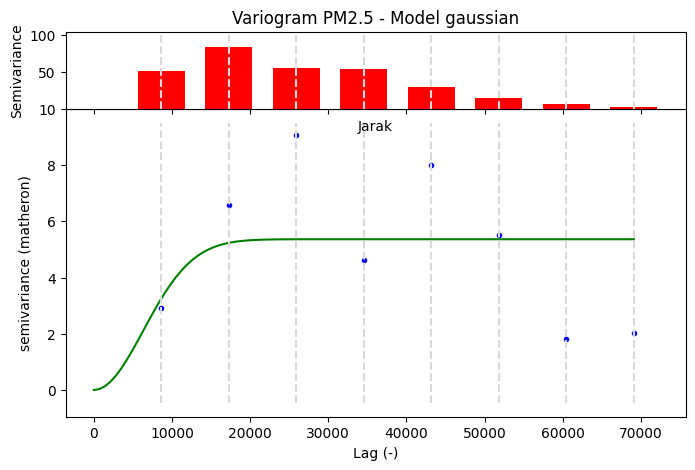

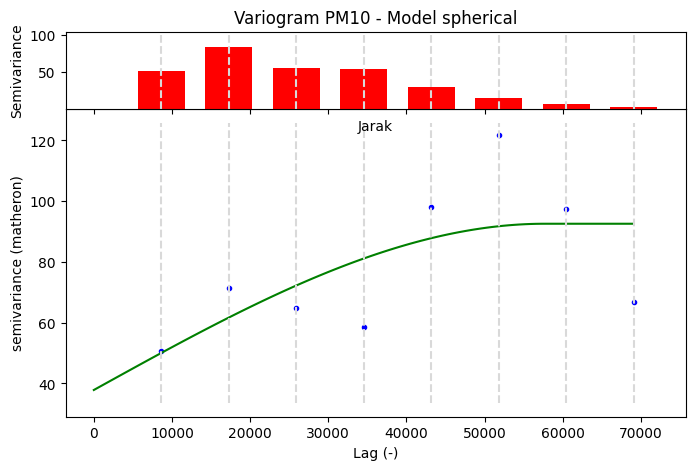


RINGKASAN SEMUA MODEL
  Variabel        Model       RMSE          RSS  \
0    PM2.5     gaussian   2.418517    46.793810   
1    PM2.5  exponential   2.541543    51.675519   
2    PM2.5       matern   2.541543    51.675519   
3    PM2.5    spherical   2.541543    51.675519   
4     PM10    spherical  17.105746  2340.852327   
5     PM10     gaussian  17.436789  2432.332959   
6     PM10       matern  17.488710  2446.839946   
7     PM10  exponential  17.921714  2569.502568   

                                           Parameter  
0  [np.float64(17881.64647005257), np.float64(5.3...  
1  [np.float64(392.2160957004089), np.float64(1.8...  
2  [np.float64(311.35559188981097), np.float64(0....  
3  [np.float64(8438.720493563356), np.float64(1.1...  
4  [np.float64(57680.1765864648), np.float64(54.7...  
5  [np.float64(62623.41713121219), np.float64(44....  
6  [np.float64(63349.94950933183), np.float64(45....  
7  [np.float64(69105.51179535856), np.float64(67....  

Hasil disimpan sebaga

In [4]:
# ============================================================
# TAHAP 3
# PEMILIHAN MODEL VARIOGRAM PM2.5 DAN PM10
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skgstat import Variogram


# ============================================================
# 1. SIAPKAN DATA
# ============================================================

# df berasal dari Tahap 2.
# Jika kernel sempat direstart, aktifkan:
# df = pd.read_csv("taiwan_air_quality_cokriging_station.csv")

coordinates = df[["X", "Y"]].values

pm25 = df["PM25"].values
pm10 = df["PM10"].values

print("Jumlah titik:", len(df))


# ============================================================
# 2. MODEL YANG AKAN DIBANDINGKAN
# ============================================================

models = [
    "spherical",
    "exponential",
    "gaussian",
    "matern"
]


# ============================================================
# 3. FUNGSI MEMBANDINGKAN MODEL
# ============================================================

def bandingkan_variogram(coordinates, values, nama_variabel):

    hasil = []
    variogram_models = {}

    for model in models:

        try:

            V = Variogram(
                coordinates,
                values,
                n_lags=8,
                model=model,
                normalize=False,
                use_nugget=True
            )

            variogram_models[model] = V

            hasil.append({
                "Variabel": nama_variabel,
                "Model": model,
                "RMSE": V.rmse,
                "RSS": V.rss,
                "Parameter": str(V.parameters)
            })

        except Exception as e:

            print(
                f"Model {model} gagal:",
                e
            )


    hasil = pd.DataFrame(hasil)

    # RMSE kecil = fitting lebih baik
    hasil = hasil.sort_values(
        "RMSE"
    ).reset_index(drop=True)

    return hasil, variogram_models


# ============================================================
# 4. BANDINGKAN MODEL PM2.5
# ============================================================

hasil_PM25, models_PM25 = bandingkan_variogram(
    coordinates,
    pm25,
    "PM2.5"
)

print("\n======================================")
print("PERBANDINGAN VARIOGRAM PM2.5")
print("======================================")

print(hasil_PM25)


# ============================================================
# 5. BANDINGKAN MODEL PM10
# ============================================================

hasil_PM10, models_PM10 = bandingkan_variogram(
    coordinates,
    pm10,
    "PM10"
)

print("\n======================================")
print("PERBANDINGAN VARIOGRAM PM10")
print("======================================")

print(hasil_PM10)


# ============================================================
# 6. MODEL DENGAN RMSE TERKECIL
# ============================================================

best_PM25 = hasil_PM25.iloc[0]["Model"]
best_PM10 = hasil_PM10.iloc[0]["Model"]

print("\n======================================")
print("MODEL DENGAN RMSE TERKECIL")
print("======================================")

print(
    "PM2.5:",
    best_PM25
)

print(
    "PM10 :",
    best_PM10
)


# ============================================================
# 7. PARAMETER MODEL TERPILIH
# ============================================================

V_PM25_best = models_PM25[best_PM25]
V_PM10_best = models_PM10[best_PM10]

print("\nParameter PM2.5:")
print(V_PM25_best.parameters)

print("\nParameter PM10:")
print(V_PM10_best.parameters)


# ============================================================
# 8. PLOT MODEL TERPILIH PM2.5
# ============================================================

V_PM25_best.plot()

plt.title(
    f"Variogram PM2.5 - Model {best_PM25}"
)

plt.xlabel("Jarak")
plt.ylabel("Semivariance")

plt.show()


# ============================================================
# 9. PLOT MODEL TERPILIH PM10
# ============================================================

V_PM10_best.plot()

plt.title(
    f"Variogram PM10 - Model {best_PM10}"
)

plt.xlabel("Jarak")
plt.ylabel("Semivariance")

plt.show()


# ============================================================
# 10. GABUNGKAN HASIL PERBANDINGAN
# ============================================================

hasil_semua = pd.concat(
    [
        hasil_PM25,
        hasil_PM10
    ],
    ignore_index=True
)

print("\n======================================")
print("RINGKASAN SEMUA MODEL")
print("======================================")

print(hasil_semua)


# ============================================================
# 11. SIMPAN HASIL
# ============================================================

hasil_semua.to_csv(
    "hasil_perbandingan_variogram.csv",
    index=False
)

print(
    "\nHasil disimpan sebagai:"
    "\nhasil_perbandingan_variogram.csv"
)